# HI 5304 — Data Analytics for Health Informatics (Jupyter Notebook)  
**Focus:** Practical analytics patterns you’ll use with EHR / claims / remote monitoring data  
**Tools:** `pandas`, `numpy`, `matplotlib` (and one optional `scikit-learn` example)

---

## Learning goals
By the end of this notebook you will be able to:
- Load tabular data into a pandas **DataFrame**
- Inspect data types, missingness, and basic distributions
- Create **derived variables** (e.g., BP category, diabetes range)
- Compute **quality metrics** (e.g., BP control rate, adherence)
- Use **groupby** to produce cohort summaries (e.g., by clinic, age group)
- Join tables (patients + vitals + medications)
- Analyze trends over time and create simple visualizations
- (Optional) Fit a simple predictive model

> This notebook uses a small **synthetic dataset** (fake data) so it runs anywhere.


## 1) Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

## 2) Create a small synthetic health informatics dataset  
In real work, these tables might come from:
- EHR exports (CSV)
- Data warehouse tables (SQL)
- Remote patient monitoring platforms (API)
- Claims datasets

We’ll create:
1) `patients` (demographics + clinic)  
2) `vitals` (BP, heart rate, glucose over time)  
3) `meds` (medication list per patient)


In [2]:
# Reproducibility
rng = np.random.default_rng(5304)

# Patients table
patients = pd.DataFrame({
    "patient_id": [f"P{1000+i}" for i in range(20)],
    "age": rng.integers(35, 81, size=20),
    "sex": rng.choice(["F", "M"], size=20),
    "clinic": rng.choice(["Clinic A", "Clinic B", "Clinic C"], size=20, p=[0.4, 0.35, 0.25]),
})

# Create a timeline of 10 dates
dates = pd.date_range("2026-02-01", periods=10, freq="3D")

# Vitals table: multiple readings per patient over time
rows = []
for pid in patients["patient_id"]:
    baseline_sys = rng.normal(135, 12)
    baseline_dia = rng.normal(85, 8)
    baseline_hr = rng.normal(74, 10)
    baseline_glu = rng.normal(110, 25)

    for d in dates:
        rows.append({
            "patient_id": pid,
            "reading_date": d,
            "systolic": int(np.clip(rng.normal(baseline_sys, 10), 90, 220)),
            "diastolic": int(np.clip(rng.normal(baseline_dia, 6), 50, 140)),
            "heart_rate": int(np.clip(rng.normal(baseline_hr, 8), 40, 180)),
            "glucose": int(np.clip(rng.normal(baseline_glu, 30), 60, 400)),
        })

vitals = pd.DataFrame(rows)

# Add some missing values (common in real-world data)
missing_idx = rng.choice(vitals.index, size=12, replace=False)
vitals.loc[missing_idx[:6], "glucose"] = np.nan
vitals.loc[missing_idx[6:], "heart_rate"] = np.nan

# Medications table: 0–3 meds per patient
med_catalog = ["lisinopril", "amlodipine", "atorvastatin", "metformin", "aspirin"]
med_rows = []
for pid in patients["patient_id"]:
    n = int(rng.integers(0, 4))
    meds_for_pid = rng.choice(med_catalog, size=n, replace=False)
    for m in meds_for_pid:
        med_rows.append({"patient_id": pid, "medication": m})
meds = pd.DataFrame(med_rows)

patients.head(), vitals.head(), meds.head()

(  patient_id  age sex    clinic
 0      P1000   42   M  Clinic C
 1      P1001   47   M  Clinic C
 2      P1002   61   F  Clinic A
 3      P1003   58   F  Clinic A
 4      P1004   39   F  Clinic A,
   patient_id reading_date  systolic  diastolic  heart_rate  glucose
 0      P1000   2026-02-01       115         78        60.0    125.0
 1      P1000   2026-02-04       111         94        72.0    139.0
 2      P1000   2026-02-07       117         83        72.0     85.0
 3      P1000   2026-02-10       145        104        67.0    128.0
 4      P1000   2026-02-13       139         93        73.0    117.0,
   patient_id    medication
 0      P1000    amlodipine
 1      P1000  atorvastatin
 2      P1000    lisinopril
 3      P1001       aspirin
 4      P1003     metformin)

## 3) Basic DataFrame inspection  
A few habits that prevent confusion later:
- `head()` to preview
- `shape` to understand size
- `info()` for data types and missingness
- `describe()` for numeric summary


In [3]:
print("patients shape:", patients.shape)
print("vitals shape:", vitals.shape)
print("meds shape:", meds.shape)

patients.info()

patients shape: (20, 4)
vitals shape: (200, 6)
meds shape: (30, 2)
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   patient_id  20 non-null     str  
 1   age         20 non-null     int64
 2   sex         20 non-null     str  
 3   clinic      20 non-null     str  
dtypes: int64(1), str(3)
memory usage: 772.0 bytes


In [4]:
vitals.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   patient_id    200 non-null    str           
 1   reading_date  200 non-null    datetime64[us]
 2   systolic      200 non-null    int64         
 3   diastolic     200 non-null    int64         
 4   heart_rate    194 non-null    float64       
 5   glucose       194 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(1)
memory usage: 9.5 KB


In [5]:
vitals.describe()

,reading_date,systolic,diastolic,heart_rate,glucose
count,200,200.000000,200.000000,194.000000,194.000000
mean,2026-02-14 12:00:00,135.415000,85.405000,75.443299,120.453608
min,2026-02-01 00:00:00,95.000000,50.000000,48.000000,60.000000
25%,2026-02-07 00:00:00,123.750000,76.000000,69.000000,93.000000
50%,2026-02-14 12:00:00,135.500000,86.000000,76.000000,120.000000
75%,2026-02-22 00:00:00,145.000000,95.000000,83.000000,144.000000
max,2026-02-28 00:00:00,195.000000,116.000000,102.000000,216.000000
std,NaN,15.494942,13.652212,10.711931,35.866049


## 4) Missing data checks (very common in health datasets)  
We’ll calculate missingness by column and decide what to do.

Typical strategies:
- Leave missing values and handle later (common)
- Impute (fill) missing values (carefully!)
- Drop rows (only when justified)


In [6]:
missing_counts = vitals.isna().sum().sort_values(ascending=False)
missing_pct = (vitals.isna().mean() * 100).round(1).sort_values(ascending=False)

pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})

,missing_count,missing_pct
heart_rate,6,3.0
glucose,6,3.0
reading_date,0,0.0
patient_id,0,0.0
diastolic,0,0.0
systolic,0,0.0


### Simple imputation example (teaching-only)  
For glucose we’ll fill missing values using the patient’s median glucose.

> In real projects, always document the decision and evaluate whether imputation is clinically appropriate.


In [7]:
vitals_imputed = vitals.copy()

vitals_imputed["glucose"] = vitals_imputed.groupby("patient_id")["glucose"].transform(
    lambda s: s.fillna(s.median())
)

# Heart rate: fill missing using overall median (simple choice for demo)
vitals_imputed["heart_rate"] = vitals_imputed["heart_rate"].fillna(vitals_imputed["heart_rate"].median())

vitals_imputed.isna().sum()

patient_id      0
reading_date    0
systolic        0
diastolic       0
heart_rate      0
glucose         0
dtype: int64

## 5) Feature engineering: Create clinically meaningful flags  
Health informatics analytics often starts by turning raw measurements into:
- Categories (Normal / Elevated / HTN)
- Flags (controlled vs uncontrolled)
- Risk strata

We’ll create:
- BP category (simplified)
- BP controlled flag (goal: < 130/<80) — **teaching example**
- Glucose category (Normal / Prediabetes / Diabetes range)


In [8]:
df = vitals_imputed.copy()

def bp_category(sys, dia):
    if sys < 120 and dia < 80:
        return "Normal"
    elif sys < 130 and dia < 80:
        return "Elevated"
    elif sys < 140 or dia < 90:
        return "HTN Stage 1"
    else:
        return "HTN Stage 2"

df["bp_category"] = [bp_category(s, d) for s, d in zip(df["systolic"], df["diastolic"])]

df["bp_controlled"] = (df["systolic"] < 130) & (df["diastolic"] < 80)

def glucose_category(g):
    if g < 100:
        return "Normal"
    elif g < 126:
        return "Prediabetes"
    else:
        return "Diabetes range"

df["glucose_category"] = df["glucose"].apply(glucose_category)

df[["patient_id", "reading_date", "systolic", "diastolic", "bp_category", "bp_controlled", "glucose", "glucose_category"]].head()

,patient_id,reading_date,systolic,diastolic,bp_category,bp_controlled,glucose,glucose_category
0,P1000,2026-02-01,115,78,Normal,True,125.0,Prediabetes
1,P1000,2026-02-04,111,94,HTN Stage 1,False,139.0,Diabetes range
2,P1000,2026-02-07,117,83,HTN Stage 1,False,85.0,Normal
3,P1000,2026-02-10,145,104,HTN Stage 2,False,128.0,Diabetes range
4,P1000,2026-02-13,139,93,HTN Stage 1,False,117.0,Prediabetes


## 6) Key quality metrics (program-level analytics)  
Examples you’ll see in quality improvement and population health:
- BP control rate
- Hypertension stage distribution
- Diabetes-range glucose prevalence


In [9]:
bp_control_rate = df["bp_controlled"].mean()
print(f"BP control rate (teaching threshold <130/<80): {bp_control_rate:.2%}")

bp_category_counts = df["bp_category"].value_counts(normalize=True).mul(100).round(1)
glucose_category_counts = df["glucose_category"].value_counts(normalize=True).mul(100).round(1)

print("\nBP category distribution (%):")
print(bp_category_counts)

print("\nGlucose category distribution (%):")
print(glucose_category_counts)

BP control rate (teaching threshold <130/<80): 10.00%

BP category distribution (%):
bp_category
HTN Stage 1    75.5
HTN Stage 2    14.5
Elevated        7.0
Normal          3.0
Name: proportion, dtype: float64

Glucose category distribution (%):
glucose_category
Diabetes range    43.5
Normal            28.5
Prediabetes       28.0
Name: proportion, dtype: float64


## 7) Cohort summaries with `groupby`  
This is one of the most important analytics patterns in pandas.

We’ll compute clinic-level summaries:
- # of unique patients
- average systolic/diastolic
- BP control rate


In [10]:
clinic_summary = (df
    .merge(patients, on="patient_id", how="left")
    .groupby("clinic")
    .agg(
        n_readings=("patient_id", "size"),
        n_patients=("patient_id", "nunique"),
        avg_systolic=("systolic", "mean"),
        avg_diastolic=("diastolic", "mean"),
        bp_control_rate=("bp_controlled", "mean"),
    )
    .sort_values("bp_control_rate", ascending=False)
)

clinic_summary.round({"avg_systolic": 1, "avg_diastolic": 1, "bp_control_rate": 3})

,n_readings,n_patients,avg_systolic,avg_diastolic,bp_control_rate
clinic,,,,,
Clinic C,40,4,131.7,91.0,0.125
Clinic B,50,5,132.9,85.3,0.100
Clinic A,110,11,137.9,83.4,0.091


## 8) Age stratification (common for reporting)  
We’ll create age groups and summarize outcomes by group.


In [11]:
patients2 = patients.copy()
patients2["age_group"] = pd.cut(
    patients2["age"],
    bins=[34, 49, 64, 80],
    labels=["35–49", "50–64", "65–80"]
)

age_summary = (df
    .merge(patients2[["patient_id", "age_group"]], on="patient_id", how="left")
    .groupby("age_group")
    .agg(
        n_patients=("patient_id", "nunique"),
        avg_systolic=("systolic", "mean"),
        bp_control_rate=("bp_controlled", "mean"),
        diabetes_range_pct=("glucose_category", lambda s: (s == "Diabetes range").mean()),
    )
)

age_summary.round({"avg_systolic": 1, "bp_control_rate": 3, "diabetes_range_pct": 3})

,n_patients,avg_systolic,bp_control_rate,diabetes_range_pct
age_group,,,,
35–49,8,131.3,0.162,0.262
50–64,5,141.5,0.000,0.660
65–80,7,135.8,0.100,0.471


## 9) Joins (merges): combining tables like in a data warehouse  
Health informatics typically uses multiple tables:
- demographics (patients)
- vitals / labs
- medications
- diagnoses
- encounters

We’ll create a patient-level medication count and join it back to the patient table.


In [12]:
med_counts = (meds
    .groupby("patient_id")
    .size()
    .rename("med_count")
    .reset_index()
)

patients_enriched = (patients
    .merge(med_counts, on="patient_id", how="left")
    .fillna({"med_count": 0})
)

patients_enriched["med_count"] = patients_enriched["med_count"].astype(int)
patients_enriched.head()

,patient_id,age,sex,clinic,med_count
0,P1000,42,M,Clinic C,3
1,P1001,47,M,Clinic C,1
2,P1002,61,F,Clinic A,0
3,P1003,58,F,Clinic A,2
4,P1004,39,F,Clinic A,1


## 10) Patient-level analytics: “latest reading”  
A common pattern is creating a **patient-level panel**:
- latest vitals
- change over time
- rolling averages

We’ll compute each patient’s **latest** BP and glucose.


In [13]:
latest = (df
    .sort_values(["patient_id", "reading_date"])
    .groupby("patient_id")
    .tail(1)
    .rename(columns={"reading_date": "latest_date"})
)

latest_patient = (patients_enriched
    .merge(latest[["patient_id", "latest_date", "systolic", "diastolic", "glucose", "bp_controlled", "heart_rate"]], on="patient_id", how="left")
)

latest_patient.head()

,patient_id,age,sex,clinic,med_count,latest_date,systolic,diastolic,glucose,bp_controlled,heart_rate
0,P1000,42,M,Clinic C,3,2026-02-28,132,83,135.0,False,73.0
1,P1001,47,M,Clinic C,1,2026-02-28,140,92,75.0,False,67.0
2,P1002,61,F,Clinic A,0,2026-02-28,155,76,147.0,False,71.0
3,P1003,58,F,Clinic A,2,2026-02-28,149,93,104.0,False,76.0
4,P1004,39,F,Clinic A,1,2026-02-28,131,73,110.0,False,58.0


## 11) Time-series analytics: program trend over time  
We’ll compute the overall average systolic BP over time and plot it.


In [14]:
trend = (df
    .groupby("reading_date")
    .agg(
        avg_systolic=("systolic", "mean"),
        bp_control_rate=("bp_controlled", "mean"),
        n_readings=("patient_id", "size")
    )
    .reset_index()
)

trend.head()

,reading_date,avg_systolic,bp_control_rate,n_readings
0,2026-02-01,134.00,0.20,20
1,2026-02-04,132.85,0.05,20
2,2026-02-07,133.25,0.15,20
3,2026-02-10,139.00,0.10,20
4,2026-02-13,131.60,0.05,20


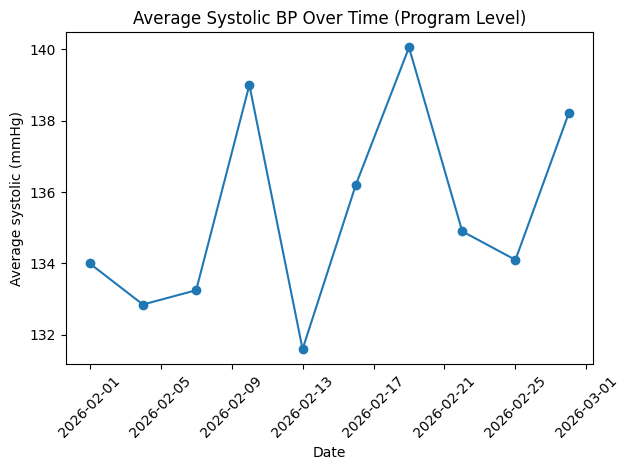

In [15]:
plt.figure()
plt.plot(trend["reading_date"], trend["avg_systolic"], marker="o")
plt.xticks(rotation=45)
plt.title("Average Systolic BP Over Time (Program Level)")
plt.xlabel("Date")
plt.ylabel("Average systolic (mmHg)")
plt.tight_layout()
plt.show()

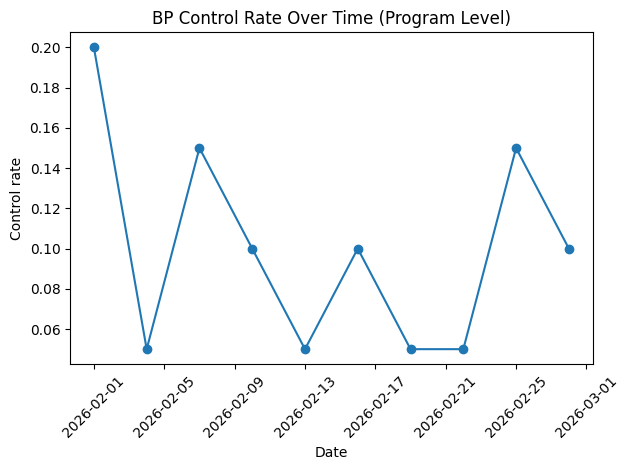

In [16]:
plt.figure()
plt.plot(trend["reading_date"], trend["bp_control_rate"], marker="o")
plt.xticks(rotation=45)
plt.title("BP Control Rate Over Time (Program Level)")
plt.xlabel("Date")
plt.ylabel("Control rate")
plt.tight_layout()
plt.show()

## 12) Outlier checks (data quality)  
Outliers in health data can be:
- True clinical extremes
- Device error
- Data entry issues
- Unit problems (e.g., mg/dL vs mmol/L)

We’ll flag extreme systolic values using the IQR method.


In [17]:
q1, q3 = df["systolic"].quantile([0.25, 0.75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df["systolic"] < lower) | (df["systolic"] > upper)].copy()
print("IQR bounds:", round(lower, 1), "to", round(upper, 1))
outliers.sort_values("systolic", ascending=False).head(10)

IQR bounds: 91.9 to 176.9


,patient_id,reading_date,systolic,diastolic,heart_rate,glucose,bp_category,bp_controlled,glucose_category
116,P1011,2026-02-19,195,75,66.0,111.0,HTN Stage 1,False,Prediabetes
115,P1011,2026-02-16,178,77,74.0,81.0,HTN Stage 1,False,Normal


## 13) (Optional) Simple predictive modeling example  
This is a minimal example of using `scikit-learn` to predict a continuous outcome.

We’ll predict **systolic BP** from:
- age
- sex (encoded)
- glucose
- heart rate
- medication count

This is a toy example meant to show the workflow (train/test split + evaluation).


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression

# Build a modeling dataset at the *latest patient* level
model_df = latest_patient.copy()

# Encode sex as 0/1
model_df["sex_male"] = (model_df["sex"] == "M").astype(int)

# Features + target
features = ["age", "sex_male", "glucose", "heart_rate", "med_count"]
X = model_df[features]
y = model_df["systolic"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=5304)

# Model
lr = LinearRegression()
lr.fit(X_train, y_train)

pred = lr.predict(X_test)
mae = mean_absolute_error(y_test, pred)

print("Mean Absolute Error (mmHg):", round(mae, 2))
pd.DataFrame({"actual_systolic": y_test.values, "predicted_systolic": pred}).head()

Mean Absolute Error (mmHg): 12.13


,actual_systolic,predicted_systolic
0,137,137.530449
1,149,135.126473
2,144,123.803734
3,120,141.750356
4,155,140.196850


## 14) Wrap-up: What you just practiced  
These are the same analytics patterns you’ll reuse constantly:
- Load data → inspect → clean
- Create derived variables (flags/categories)
- Summarize overall metrics
- Summarize by subgroup (clinic, age group)
- Join tables
- Track trends over time
- Check data quality and outliers
- (Optional) fit a simple model

### Suggested next notebook
- Read a real CSV file (provided in the course)
- Repeat this same workflow and produce a short “analytics report”
